In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch
from torchvision import transforms

# Exploratory data analysis
This notebook is used to take a first peek at the data. The project deals with the following two datasets:
- The skin lesion segmentation dataset PH2 (folder: "/dtu/datasets1/02516/PH2_Dataset_images")
- The retinal blood vessel segmentation dataset DRIVE (folder: "/dtu/datasets1/02516/DRIVE")

## PH2
### Folder structure
```
├── IMD002                              
│   │
│   ├── IMD002_Dermoscopic_Image        
│   │   │
│   │   └── IMD002.bmp
│   │
│   ├── IMD002_lesion                   
│   │   │
│   │   └── IMD002_lesion.bmp
│   │
│   └── IMD002_roi                      
│       │
│       ├── IMD002_R1_Label4.bmp
│       │
│       └── IMD002_R2_Label3.bmp
│
└── ...                                  <- 199 other folders named IMDxxx (gaps between 002 and 437)
```

Displaying some of the images:

Dermoscopic tensor shape: torch.Size([3, 572, 765])
Lesion tensor shape: torch.Size([1, 572, 765])
ROI 1 tensor shape: torch.Size([1, 572, 765])
ROI 2 tensor shape: torch.Size([1, 572, 765])


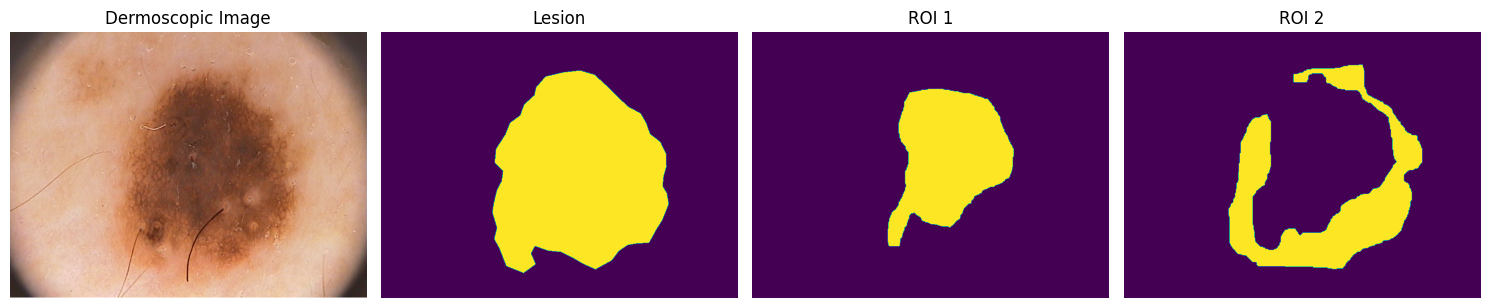

In [17]:
# base path to PH2 dataset
base_path = "/dtu/datasets1/02516/PH2_Dataset_images"

# folder to visualize
folder = "IMD002"

# full paths
dermoscopic_path = os.path.join(base_path, folder, f"{folder}_Dermoscopic_Image", f"{folder}.bmp")
lesion_path = os.path.join(base_path, folder, f"{folder}_lesion", f"{folder}_lesion.bmp")
roi_folder = os.path.join(base_path, folder, f"{folder}_roi")

# initializing transformer
to_tensor = transforms.ToTensor()

# loading images
dermoscopic_img = Image.open(dermoscopic_path).convert("RGB")
lesion_img = Image.open(lesion_path).convert("L")

# converting to tensors
dermoscopic_tensor = to_tensor(dermoscopic_img)
lesion_tensor = to_tensor(lesion_img)

# obtaining ROI images (if any)
roi_images = []
roi_tensors = []
if os.path.exists(roi_folder):
    roi_files = [f for f in os.listdir(roi_folder) if f.endswith(".bmp")]
    for f in roi_files:
        roi_img = Image.open(os.path.join(roi_folder, f)).convert("L") 
        roi_images.append(roi_img)
        roi_tensors.append(to_tensor(roi_img))

# displaying image sizes
print("Dermoscopic tensor shape:", dermoscopic_tensor.shape)
print("Lesion tensor shape:", lesion_tensor.shape)
for i, roi_tensor in enumerate(roi_tensors):
    print(f"ROI {i+1} tensor shape:", roi_tensor.shape)

# displaying images
fig, axes = plt.subplots(1, 2 + len(roi_images), figsize=(15, 5))

# dermoscopic
axes[0].imshow(dermoscopic_img)
axes[0].set_title("Dermoscopic Image")
axes[0].axis("off")

# lesion
axes[1].imshow(lesion_img)
axes[1].set_title("Lesion")
axes[1].axis("off")

# ROIs
for i, roi in enumerate(roi_images):
    axes[2 + i].imshow(roi)
    axes[2 + i].set_title(f"ROI {i+1}")
    axes[2 + i].axis("off")

plt.tight_layout()
plt.show()

Comments:
- The dermoscopic images are the main input to the segmentation model
- The lesions are what the output are being compared to
- Each leasion is basically a tensor containing pixel classifications (each pixel is either 0 or 1)
- The ROIs can be used for pre-processing by cropping the dermoscopic image or for evaluation purposes by ignoring the background that is not a part of the ROI
- Binary segmentation (either a pixel is part of the lesion or not)

## DRIVE
### Folder structure
```
├── test                         
│   │
│   ├── images        
│   │   │
│   │   ├─── 01_test.tif
│   │   │
│   │   ├─── ...
│   │   │
│   │   └─── 20_test.tif
│   │
│   └── mask                  
│       │
│       ├─── 01_test_mask.gif
│       │
│       ├─── ...
│       │
│       └─── 20_test_mask.gif
│    
└── training                     
    │
    ├── 1st_manual       
    │   │
    │   ├─── 21_manual1.gif
    │   │
    │   ├─── ...
    │   │
    │   └─── 40_manual1.gif
    │
    ├── images                  
    │   │
    │   ├─── 21_training.tif
    │   │
    │   ├─── ...
    │   │
    │   └─── 40_training.tif
    |
    └── mask                  
        │
        ├─── 21_training_mask.gif
        │
        ├─── ...
        │
        └─── 40_training_mask.tif

```

Displaying a test image:

Image tensor shape: torch.Size([3, 584, 565])
Mask tensor shape: torch.Size([1, 584, 565])


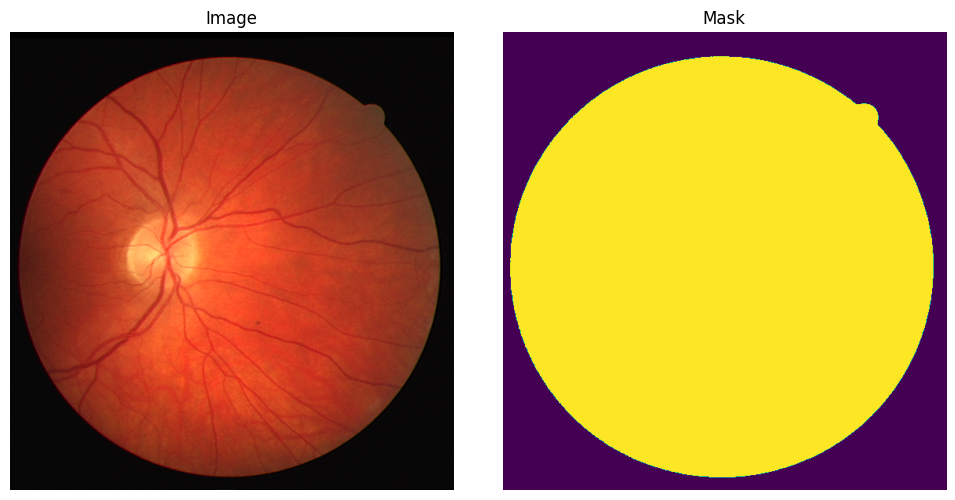

In [ ]:
# base path to DRIVE test set
base_path = "/dtu/datasets1/02516/DRIVE/test"

# folder and image to visualize
image_name = "15_test"

# full paths
image_path = os.path.join(base_path, "images", f"{image_name}.tif")
mask_path = os.path.join(base_path, "mask", f"{image_name}_mask.gif")

# initializing transformer
to_tensor = transforms.ToTensor()

# loading images
image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

# converting to tensors
image_tensor = to_tensor(image)
mask_tensor = to_tensor(mask)

# displaying image sizes
print("Image tensor shape:", image_tensor.shape)
print("Mask tensor shape:", mask_tensor.shape)

# displaying images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# dermoscopic
axes[0].imshow(image)
axes[0].set_title("Image")
axes[0].axis("off")

# lesion
axes[1].imshow(mask)
axes[1].set_title("Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Displaying a training image:

Manual tensor shape: torch.Size([1, 584, 565])
Image tensor shape: torch.Size([3, 584, 565])
Mask tensor shape: torch.Size([1, 584, 565])


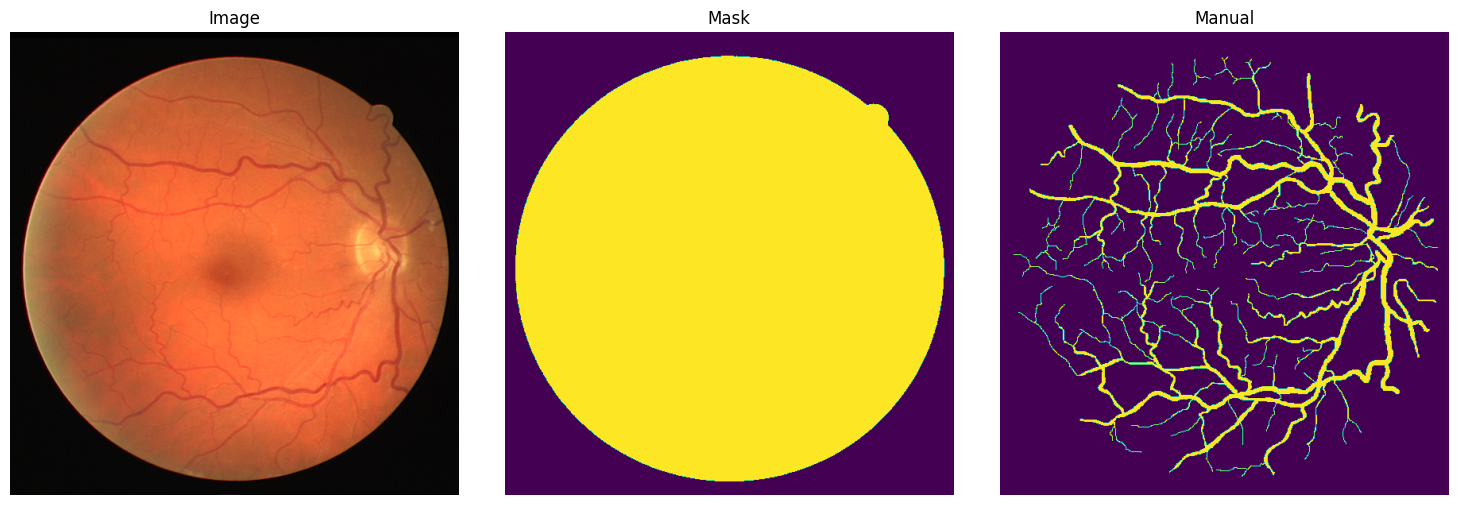

In [26]:
# base path to DRIVE train set
base_path = "/dtu/datasets1/02516/DRIVE/training"

# folder and image to visualize
image_number = "22"

# full paths
manual_path = os.path.join(base_path, "1st_manual", f"{image_number}_manual1.gif")
image_path = os.path.join(base_path, "images", f"{image_number}_training.tif")
mask_path = os.path.join(base_path, "mask", f"{image_number}_training_mask.gif")

# initializing transformer
to_tensor = transforms.ToTensor()

# loading images
manual = Image.open(manual_path).convert("L")
image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

# converting to tensors
manual_tensor = to_tensor(manual)
image_tensor = to_tensor(image)
mask_tensor = to_tensor(mask)

# displaying image sizes
print("Manual tensor shape:", manual_tensor.shape)
print("Image tensor shape:", image_tensor.shape)
print("Mask tensor shape:", mask_tensor.shape)

# displaying images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# image
axes[0].imshow(image)
axes[0].set_title("Image")
axes[0].axis("off")

# mask
axes[1].imshow(mask)
axes[1].set_title("Mask")
axes[1].axis("off")

# manual
axes[2].imshow(manual)
axes[2].set_title("Manual")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Comments:
- We should use the manual mask (to the right above), not the mask in the middle that segments the non-black part out
- The test images do not have this type of mask, how do we evaluate on those images?